In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [8]:
pd.set_option('display.max_columns', None)

In [10]:
print(df.shape)

(1143, 13)


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None


In [12]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [13]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


## Visulization

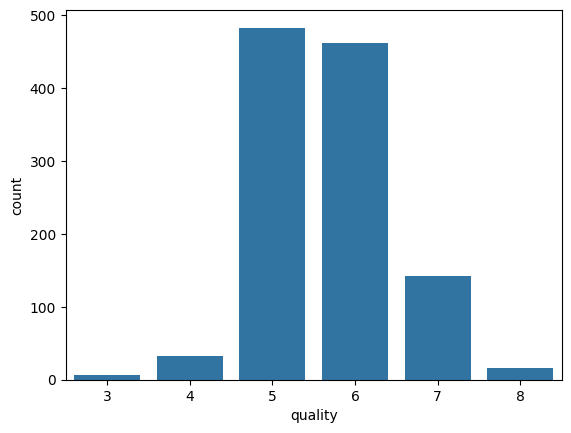

In [20]:
sns.countplot(x= 'quality', data = df)
plt.show()

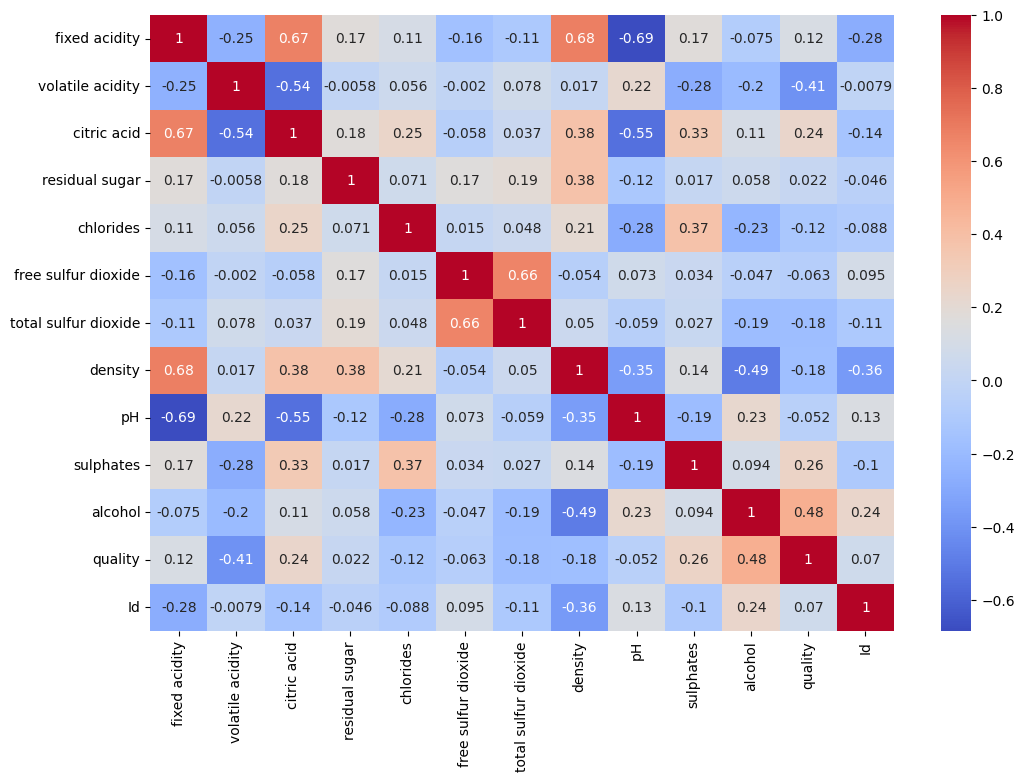

In [21]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, cmap= 'coolwarm')
plt.show()

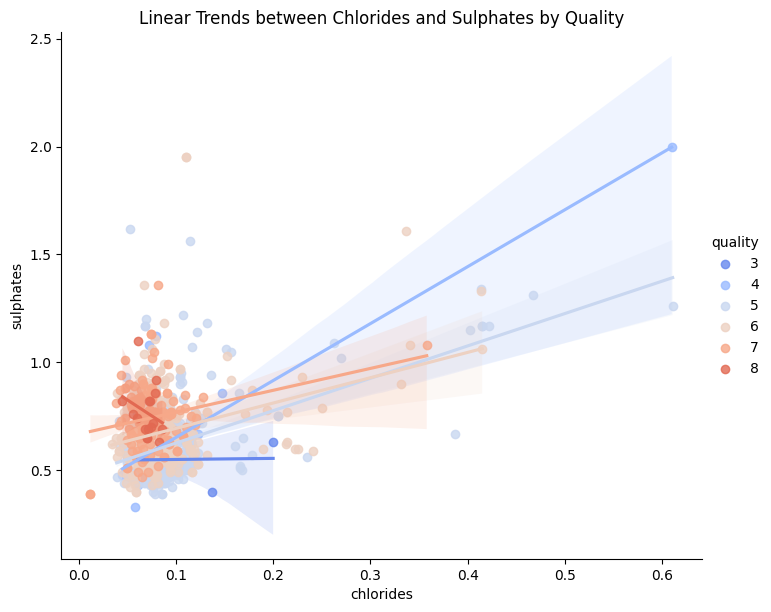

In [28]:
# lmplot automatically adds the linear relationship line for each quality group
sns.lmplot(
    data=df, 
    x='chlorides', 
    y='sulphates', 
    hue='quality', 
    palette='coolwarm',
    height=6,      # Adjusts the size of the plot
    aspect=1.2
)

plt.title('Linear Trends between Chlorides and Sulphates by Quality')
plt.show()


In [23]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


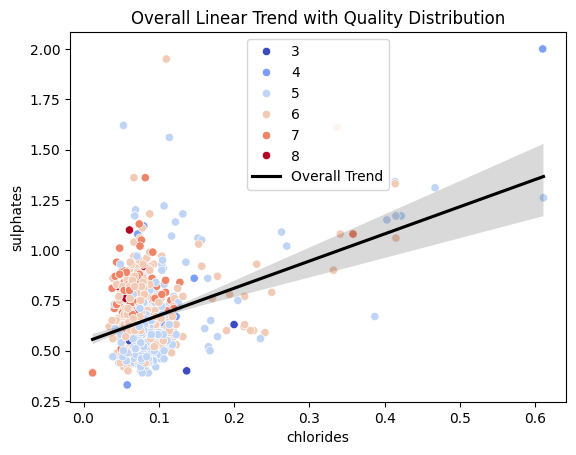

In [32]:
# 1. Plot the color-coded points
sns.scatterplot(data=df, x='chlorides', y='sulphates', hue='quality', palette='coolwarm')

# 2. Overlay a single overall linear relationship line (scatter=False prevents doubling the points)
sns.regplot(data=df, x='chlorides', y='sulphates', scatter=False, color='black', label='Overall Trend')

plt.title('Overall Linear Trend with Quality Distribution')
plt.legend()
plt.show()


In [33]:
# Features selection

X = df.drop('quality', axis=1)
y = df['quality']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Models
Logistic Regression

In [36]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [37]:
# Decision Tree Classifier
dt = DecisionTreeClassifier()

dt.fit(X_train_scaled, y_train)

pred_dt = dt.predict(X_test_scaled)

In [38]:
#random forest classifier
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)

pred_rf = rf.predict(X_test_scaled)

In [39]:
# Evaluate Models

In [40]:
# Logistic Regression
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, pred_lr))

# Decision Tree Classifier
print("Decision Tree Classifier:")
print("Accuracy:", accuracy_score(y_test, pred_dt))

# Random Forest Classifier
print("Random Forest Classifier:")
print("Accuracy:", accuracy_score(y_test, pred_rf))

Logistic Regression:
Accuracy: 0.6375545851528385
Decision Tree Classifier:
Accuracy: 0.5502183406113537
Random Forest Classifier:
Accuracy: 0.6943231441048034


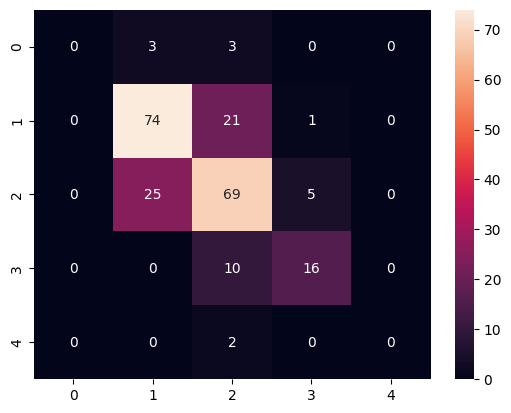

In [41]:
# Confusion Matrix 
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt="d")

plt.show()

In [43]:
#classification report
print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test, pred_rf))

Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.73      0.77      0.75        96
           6       0.66      0.70      0.68        99
           7       0.73      0.62      0.67        26
           8       0.00      0.00      0.00         2

    accuracy                           0.69       229
   macro avg       0.42      0.42      0.42       229
weighted avg       0.67      0.69      0.68       229



f:\python1\venv1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\python1\venv1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\python1\venv1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [44]:
# Feature Importance from Random Forest
importance = rf.feature_importances_

features = X.columns

feature_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_imp = feature_imp.sort_values(
    by="Importance",
    ascending=False
)

print(feature_imp)

                 Feature  Importance
10               alcohol    0.131086
9              sulphates    0.110303
1       volatile acidity    0.105950
6   total sulfur dioxide    0.089680
11                    Id    0.080225
7                density    0.080106
4              chlorides    0.074476
2            citric acid    0.070459
0          fixed acidity    0.068210
8                     pH    0.068047
3         residual sugar    0.061283
5    free sulfur dioxide    0.060176
